# Testing decision tree for JYXFE, PCA data
Concierto de Aranjuez - Paco de Lucía

In [1]:
from sklearn import tree
import pandas as pd
from pathlib import Path

input_path = Path(
    "/home/tperezsanchez/FoundationModel_EEG_Dissertation/Main_project/results/JYXFE/Feature_ext/Part2_features/JYXFE_IN-normalized_npz_FP-fullnpz_W10s_PRE6to5min_ICT0to1min_GAPasINT_FINAL-PREvsSEIZ_20260511_v01_FEAT-TIME-FREQ_20260511_v01/df_windows_JYXFEpca.pkl"
)
df_windows_pca = pd.read_pickle(input_path)

print("Loaded dataframe:")
print("Shape:", df_windows_pca.shape)

df_windows_pca.head()


Loaded dataframe:
Shape: (322, 21)


,file_name,window_id,start_sample,end_sample,fs,n_channels,window_sec,seizure_onsets,window_start_time,window_end_time,...,label_name,excluded_reason,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,JYXFE_22_preproc_full.npz,983,2034810,2036880,207.031055,2,10,[2021-05-04 20:33:31.000000],2021-05-04 20:27:26.525499679,2021-05-04 20:27:36.523999679,...,preictal,None,-1.064052,1.294069,-0.460270,0.234506,-1.516932,-0.591967,-0.338460,0.151425
1,JYXFE_22_preproc_full.npz,984,2036880,2038950,207.031055,2,10,[2021-05-04 20:33:31.000000],2021-05-04 20:27:36.523999679,2021-05-04 20:27:46.522499678,...,preictal,None,-0.073443,0.087551,0.021230,-0.016202,0.061701,-0.904050,-0.185532,-0.525385
2,JYXFE_22_preproc_full.npz,985,2038950,2041020,207.031055,2,10,[2021-05-04 20:33:31.000000],2021-05-04 20:27:46.522499678,2021-05-04 20:27:56.520999678,...,preictal,None,-2.117653,-0.646321,-0.576643,-0.112017,0.019424,-0.528235,-0.108909,0.264217
3,JYXFE_22_preproc_full.npz,986,2041020,2043090,207.031055,2,10,[2021-05-04 20:33:31.000000],2021-05-04 20:27:56.520999678,2021-05-04 20:28:06.519499678,...,preictal,None,-1.882690,0.041619,-0.415088,-0.582671,-0.208340,-0.325644,-0.157236,-0.144719
4,JYXFE_22_preproc_full.npz,987,2043090,2045160,207.031055,2,10,[2021-05-04 20:33:31.000000],2021-05-04 20:28:06.519499678,2021-05-04 20:28:16.517999678,...,preictal,None,-1.701949,-0.809071,-0.416796,-0.764038,0.032930,-0.341327,-0.049809,-0.322452


## 2. QC

In [2]:
df_RandomFor = df_windows_pca.copy()
df_RandomFor["window_start_time"] = pd.to_datetime(df_RandomFor["window_start_time"])
df_RandomFor  = df_RandomFor.sort_values("window_start_time").reset_index(drop=True)

In [3]:
print(df_RandomFor["window_start_time"].head())
print(df_RandomFor["window_start_time"].tail())
# it checks with mapping, as it is the last day of recording (2019-12-11)

0   2021-05-04 20:27:26.525499679
1   2021-05-04 20:27:36.523999679
2   2021-05-04 20:27:46.522499678
3   2021-05-04 20:27:56.520999678
4   2021-05-04 20:28:06.519499678
Name: window_start_time, dtype: datetime64[ns]
317   2022-04-13 12:31:43.109999589
318   2022-04-13 12:31:53.108499589
319   2022-04-13 12:32:03.106999588
320   2022-04-13 12:32:13.105499588
321   2022-04-13 12:32:23.103999588
Name: window_start_time, dtype: datetime64[ns]


In [4]:
df_RandomFor = df_RandomFor.dropna(axis=1, how="all").copy()

metadata_cols = [
    "window_id",
    "start_sample",
    "end_sample",
    "fs",
    "n_channels",
    "window_sec",
    "seizure_onsets",
    "file_name",
    "window_start_time",
    "window_end_time",
    "class_label",
    "label_name"
]

feature_cols = [col for col in df_RandomFor.columns if col not in metadata_cols]

X = df_RandomFor[feature_cols].copy()
y = df_RandomFor["class_label"].copy()

print("df_RandomFor shape:", df_RandomFor.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("NaNs in X:", X.isna().sum().sum())
print("Class counts:")
print(y.value_counts())

df_RandomFor shape: (322, 20)
X shape: (322, 8)
y shape: (322,)
NaNs in X: 0
Class counts:
class_label
1    161
2    161
Name: count, dtype: int64


In [5]:
import numpy as np

# -------------------------------
# 1. Define target variable
# -------------------------------
y = df_RandomFor["class_label"].copy()

# -------------------------------
# 2. Drop metadata, identifiers, temporal info, target columns,
#    and columns that are not EEG-derived features
# -------------------------------
cols_to_drop = [
    "file_name",
    "window_id",
    "start_sample",
    "end_sample",
    "fs",
    "n_channels",
    "window_sec",
    "seizure_onsets",
    "window_start_time",
    "window_end_time",
    "class_label",
    "label_name",
    "excluded_reason"   # important: this column is completely empty
]

# Drop only columns that actually exist
cols_to_drop = [col for col in cols_to_drop if col in df_RandomFor.columns]

X = df_RandomFor.drop(columns=cols_to_drop).copy()

# -------------------------------
# 3. Keep only numeric EEG-derived features
# -------------------------------
X = X.select_dtypes(include=[np.number])

# -------------------------------
# 4. Replace infinite values with NaN
# -------------------------------
X = X.replace([np.inf, -np.inf], np.nan)

# -------------------------------
# 5. Keep only rows without missing values in EEG features
# -------------------------------
mask = X.notna().all(axis=1)

X = X.loc[mask].copy()
y = y.loc[mask].copy()

# -------------------------------
# 6. Remove constant columns
# -------------------------------
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
X = X.drop(columns=constant_cols)

# -------------------------------
# 7. Sanity checks
# -------------------------------
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Removed constant columns:", constant_cols)
print("Total NaNs in X:", X.isna().sum().sum())
print("Class counts:")
print(y.value_counts())

X shape: (322, 8)
y shape: (322,)
Removed constant columns: []
Total NaNs in X: 0
Class counts:
class_label
1    161
2    161
Name: count, dtype: int64


In [6]:
# Convert labels to binary format:
# 0 = preictal
# 1 = seizure
y_binary = y.map({
    1: 0,
    2: 1
})

print(y_binary.value_counts())
y = y_binary.copy()

class_label
0    161
1    161
Name: count, dtype: int64


In [7]:
# y.mean() corresponds to the proportion of class 1 (seizure)
global_ratio = y.mean()
print("Global seizure ratio:", global_ratio)

Global seizure ratio: 0.5


## 3. Split

In [8]:
# Use the cleaned dataset size, not the original dataframe size
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

n = len(X)

ideal_train = 0.70
ideal_val = 0.15
ideal_test = 0.15

# Possible positions where training ends
train_candidates = range(
    int(0.70 * n),
    int(0.90 * n),
    max(1, n // 1000)
)

# Possible validation set sizes
val_candidates = range(
    int(0.05 * n),
    int(0.20 * n),
    max(1, n // 1000)
)

# Search for the best temporal split
best = None
best_score = np.inf

In [9]:
# This procedure creates a temporal split by preserving the chronological order
# of the samples, while selecting the train/validation/test boundaries that
# best match the desired split proportions and maintain class ratios close to
# the global dataset distribution.
for train_end in train_candidates:
    for val_size in val_candidates:
        val_end = train_end + val_size

        if val_end >= n:
            continue

        # temporal subsets because df is already sorted by window_start_time
        # SPLIT STARTS HERE
        y_train = y.iloc[:train_end]
        y_val = y.iloc[train_end:val_end]
        y_test = y.iloc[val_end:]

        # require both classes in every split
        # MAKE SURE OF THE PRESENCE OF EACH CLASS IN EVERY SET
        if y_train.nunique() < 2 or y_val.nunique() < 2 or y_test.nunique() < 2:
            continue

        # size closeness to 70/15/15
        # measure how close is to the ideal proportion
        train_frac = len(y_train) / n
        val_frac = len(y_val) / n
        test_frac = len(y_test) / n

        size_score = (
            abs(train_frac - 0.70) +
            abs(val_frac - 0.15) +
            abs(test_frac - 0.15)
        )

        # class ratio closeness to global ratio
        # measure how close is the preictal proportions 
        ratio_score = (
            abs(y_train.mean() - global_ratio) +
            abs(y_val.mean() - global_ratio) +
            abs(y_test.mean() - global_ratio)
        )

        # combined score for choosing the best score
        score = size_score + ratio_score * 3

        if score < best_score:
            best_score = score
            best = (train_end, val_end)


In [10]:
# Unpack the best split boundaries found previously
# train_end = index where the training set stops
# val_end = index where the validation set stops
train_end, val_end = best

# Create the training set:
# from the beginning of the dataset up to train_end (excluded)
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

# Create the validation set:
# from train_end up to val_end (excluded)
X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

# Create the test set:
# from val_end to the end of the dataset
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

In [11]:
print("\nSet sizes:")
print(f"Train: {len(X_train)} ({len(X_train)/n:.3%})")
print(f"Val:   {len(X_val)} ({len(X_val)/n:.3%})")
print(f"Test:  {len(X_test)} ({len(X_test)/n:.3%})")

print("\nSeizure ratios:")
print(f"Global: {y.mean():.5f}")
print(f"Train:  {y_train.mean():.5f}")
print(f"Val:    {y_val.mean():.5f}")
print(f"Test:   {y_test.mean():.5f}")

print("\nTime ranges:")
print("Train:", df_RandomFor.loc[0, "window_start_time"], "->", df_RandomFor.loc[train_end - 1, "window_start_time"])
print("Val:  ", df_RandomFor.loc[train_end, "window_start_time"], "->", df_RandomFor.loc[val_end - 1, "window_start_time"])
print("Test: ", df_RandomFor.loc[val_end, "window_start_time"], "->", df_RandomFor.loc[n - 1, "window_start_time"])


Set sizes:
Train: 225 (69.876%)
Val:   42 (13.043%)
Test:  55 (17.081%)

Seizure ratios:
Global: 0.50000
Train:  0.49778
Val:    0.50000
Test:   0.50909

Time ranges:
Train: 2021-05-04 20:27:26.525499679 -> 2021-08-08 21:16:33.600999913
Val:   2021-08-08 21:16:43.599499912 -> 2021-11-26 09:46:55.495499673
Test:  2021-11-26 09:47:05.493999672 -> 2022-04-13 12:32:23.103999588


## 4. Decision tree

In [12]:
# ==========================================================
# DECISION TREE CLASSIFIER
# ==========================================================

# Import the required tools from scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# ----------------------------------------------------------
# 1. Build the Decision Tree pipeline
# ----------------------------------------------------------
# A Decision Tree does not need StandardScaler because it does not depend
# on distances between points. It works by creating decision rules such as:
# "if PC1 <= value, go left; otherwise, go right".
#
# class_weight="balanced" helps the model compensate if one class is more
# frequent than the other. In your case the classes are fairly balanced,
# but it is still a safe option.
pipeline_dt = Pipeline([
    ("tree", DecisionTreeClassifier(
        random_state=42,          # Makes results reproducible
        class_weight="balanced"   # Gives balanced importance to both classes
    ))
])

# ----------------------------------------------------------
# 2. Define temporal cross-validation
# ----------------------------------------------------------
# TimeSeriesSplit keeps the chronological order of the data.
# This is important for EEG windows because random splitting can create
# temporal leakage between train and validation data.
tscv = TimeSeriesSplit(n_splits=4)

# ----------------------------------------------------------
# 3. Define the hyperparameter grid
# ----------------------------------------------------------
# These are the combinations that GridSearchCV will test.
#
# criterion:
#   - "gini" and "entropy" are two ways to measure how good a split is.
#
# max_depth:
#   - Controls how deep the tree can grow.
#   - Smaller depth = simpler model, less overfitting.
#   - None = the tree can grow fully, but this may overfit.
#
# min_samples_split:
#   - Minimum number of samples required to split a node.
#
# min_samples_leaf:
#   - Minimum number of samples required in a final leaf.
#   - Higher values make the tree smoother and less likely to overfit.
param_grid_dt = {
    "tree__criterion": ["gini", "entropy"],
    "tree__max_depth": [2, 3, 4, 5, 6, None],
    "tree__min_samples_split": [2, 5, 10, 20],
    "tree__min_samples_leaf": [1, 2, 5, 10]
}

# ----------------------------------------------------------
# 4. Set up GridSearchCV
# ----------------------------------------------------------
# GridSearchCV trains many Decision Trees using different hyperparameters.
# It uses cross-validation inside the training set only.
#
# scoring="f1_macro":
#   - This evaluates both classes equally.
#   - Useful because you care about both preictal and seizure performance.
#
# refit=True:
#   - After finding the best parameters, it retrains the best model
#     using all X_train and y_train.
grid_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    scoring="f1_macro",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# ----------------------------------------------------------
# 5. Train the Decision Tree model
# ----------------------------------------------------------
# IMPORTANT:
# The model is trained only on the training set.
# Validation and test sets are not used during training.
grid_dt.fit(X_train, y_train)

# ----------------------------------------------------------
# 6. Save the best Decision Tree model
# ----------------------------------------------------------
# This is the final optimized Decision Tree selected by GridSearchCV.
best_model_dt = grid_dt.best_estimator_

# Print the best hyperparameters found
print("Best Decision Tree parameters:")
print(grid_dt.best_params_)

# Print the best cross-validation macro F1 score
print("\nBest mean CV macro F1:")
print(grid_dt.best_score_)

Fitting 4 folds for each of 192 candidates, totalling 768 fits
Best Decision Tree parameters:
{'tree__criterion': 'gini', 'tree__max_depth': 2, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 20}

Best mean CV macro F1:
0.5782810555481561


In [13]:
# EVALUATION FUNCTIONS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

# -------------------------------------------------
# Class names
# -------------------------------------------------
class_names = ["preictal", "seizure"]

# -------------------------------------------------
# Function: plot confusion matrix as percentages
# -------------------------------------------------
def plot_confusion_matrix_percent(y_true, y_pred, class_names, title="Confusion Matrix"):
    """
    Plot a row-normalized confusion matrix in percentage format.
    Each row sums to 100%.
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_percent, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted label",
        ylabel="True label",
        title=title
    )

    # Rotate x-axis labels if needed
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Add percentage text inside each cell
    for i in range(cm_percent.shape[0]):
        for j in range(cm_percent.shape[1]):
            value = cm_percent[i, j]
            ax.text(
                j, i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="black"
            )

    plt.tight_layout()
    plt.show()

    return cm, cm_percent

# -------------------------------------------------
# Function: evaluate model on a dataset
# -------------------------------------------------
def evaluate_and_plot(model, X_data, y_true, class_names, dataset_name="Validation"):
    """
    1. Predicts labels
    2. Prints classification table
    3. Prints global metrics
    4. Plots confusion matrix in percentages
    """
    y_pred = model.predict(X_data)

    # Classification report as dataframe
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report).T

    # Global metrics
    print(f"\n{'='*40}")
    print(f"{dataset_name.upper()} SET")
    print(f"{'='*40}")

    print("\nClassification table:")
    print(report_df)

    print("\nGlobal metrics:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.4f}")
    print(f"Macro F1: {f1_score(y_true, y_pred, average='macro'):.4f}")

    # Plot confusion matrix in percentages
    cm_counts, cm_percent = plot_confusion_matrix_percent(
        y_true=y_true,
        y_pred=y_pred,
        class_names=class_names,
        title=f"{dataset_name} Confusion Matrix (%)"
    )

    # Optional: also return as dataframes
    cm_counts_df = pd.DataFrame(
        cm_counts,
        index=[f"True {c}" for c in class_names],
        columns=[f"Pred {c}" for c in class_names]
    )

    cm_percent_df = pd.DataFrame(
        cm_percent,
        index=[f"True {c}" for c in class_names],
        columns=[f"Pred {c}" for c in class_names]
    )

    return {
        "y_pred": y_pred,
        "classification_table": report_df,
        "confusion_counts": cm_counts_df,
        "confusion_percent": cm_percent_df
    }


VALIDATION - DECISION TREE SET

Classification table:
              precision    recall  f1-score    support
preictal       0.555556  0.476190  0.512821  21.000000
seizure        0.541667  0.619048  0.577778  21.000000
accuracy       0.547619  0.547619  0.547619   0.547619
macro avg      0.548611  0.547619  0.545299  42.000000
weighted avg   0.548611  0.547619  0.545299  42.000000

Global metrics:
Accuracy: 0.5476
Balanced accuracy: 0.5476
Macro F1: 0.5453


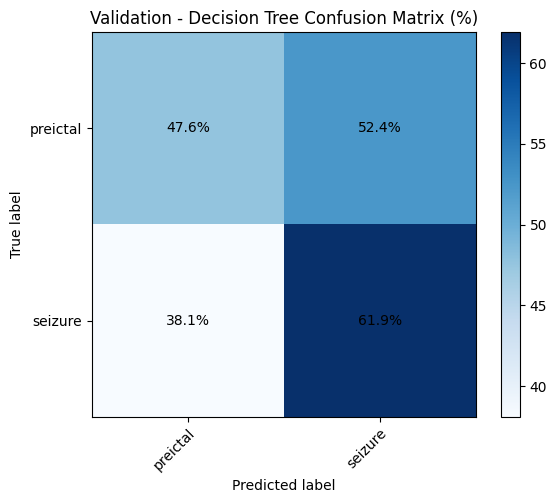


TEST - DECISION TREE SET

Classification table:
              precision    recall  f1-score    support
preictal       0.343750  0.407407  0.372881  27.000000
seizure        0.304348  0.250000  0.274510  28.000000
accuracy       0.327273  0.327273  0.327273   0.327273
macro avg      0.324049  0.328704  0.323696  55.000000
weighted avg   0.323691  0.327273  0.322801  55.000000

Global metrics:
Accuracy: 0.3273
Balanced accuracy: 0.3287
Macro F1: 0.3237


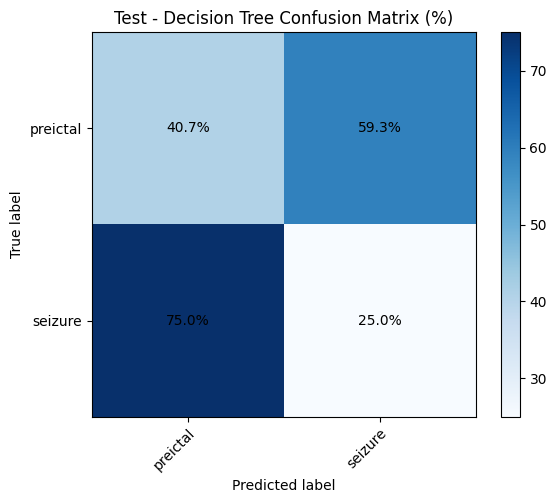

In [14]:
# ==========================================================
# EVALUATE DECISION TREE
# ==========================================================

class_names = ["preictal", "seizure"]

# Evaluate on validation set
val_results_dt = evaluate_and_plot(
    model=best_model_dt,
    X_data=X_val,
    y_true=y_val,
    class_names=class_names,
    dataset_name="Validation - Decision Tree"
)

# Evaluate on test set
test_results_dt = evaluate_and_plot(
    model=best_model_dt,
    X_data=X_test,
    y_true=y_test,
    class_names=class_names,
    dataset_name="Test - Decision Tree"
)

## 5. Random forest

In [15]:
# ==========================================================
# RANDOM FOREST CLASSIFIER
# ==========================================================

# Import the Random Forest classifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# ----------------------------------------------------------
# 1. Build the Random Forest pipeline
# ----------------------------------------------------------
# Random Forest is an ensemble model.
# This means it trains many Decision Trees and combines their predictions.
#
# Instead of relying on one tree, many trees vote for the final class.
# This usually makes Random Forest more stable and less prone to overfitting
# than a single Decision Tree.
#
# Like Decision Trees, Random Forest does not need StandardScaler.
pipeline_rf = Pipeline([
    ("forest", RandomForestClassifier(
        random_state=42,          # Makes results reproducible
        class_weight="balanced",  # Balances class importance
        n_jobs=-1                 # Uses all available CPU cores
    ))
])

# ----------------------------------------------------------
# 2. Define temporal cross-validation
# ----------------------------------------------------------
# Again, TimeSeriesSplit is used because your EEG windows have temporal order.
tscv = TimeSeriesSplit(n_splits=4)

# ----------------------------------------------------------
# 3. Define the hyperparameter grid
# ----------------------------------------------------------
# n_estimators:
#   - Number of trees in the forest.
#   - More trees usually give more stable results but take longer.
#
# max_depth:
#   - Maximum depth of each tree.
#   - Smaller depth reduces overfitting.
#
# min_samples_split:
#   - Minimum number of samples needed to split a node.
#
# min_samples_leaf:
#   - Minimum number of samples allowed in a final leaf.
#
# max_features:
#   - Number of features considered when making each split.
#   - "sqrt" is a common default for classification.
param_grid_rf = {
    "forest__n_estimators": [100, 200, 500],
    "forest__max_depth": [3, 5, 10, None],
    "forest__min_samples_split": [2, 5, 10],
    "forest__min_samples_leaf": [1, 2, 5, 10],
    "forest__max_features": ["sqrt", "log2", None]
}

# ----------------------------------------------------------
# 4. Set up GridSearchCV
# ----------------------------------------------------------
# GridSearchCV will train many Random Forest models using different
# combinations of hyperparameters.
#
# It selects the best model based on macro F1 score.
grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# ----------------------------------------------------------
# 5. Train the Random Forest model
# ----------------------------------------------------------
# Only the training set is used here.
grid_rf.fit(X_train, y_train)

# ----------------------------------------------------------
# 6. Save the best Random Forest model
# ----------------------------------------------------------
best_model_rf = grid_rf.best_estimator_

# Print the best hyperparameters found
print("Best Random Forest parameters:")
print(grid_rf.best_params_)

# Print the best cross-validation macro F1 score
print("\nBest mean CV macro F1:")
print(grid_rf.best_score_)

Fitting 4 folds for each of 432 candidates, totalling 1728 fits
Best Random Forest parameters:
{'forest__max_depth': 3, 'forest__max_features': None, 'forest__min_samples_leaf': 2, 'forest__min_samples_split': 10, 'forest__n_estimators': 200}

Best mean CV macro F1:
0.588479386818732



VALIDATION - RANDOM FOREST SET

Classification table:
              precision    recall  f1-score    support
preictal       0.428571  0.285714  0.342857  21.000000
seizure        0.464286  0.619048  0.530612  21.000000
accuracy       0.452381  0.452381  0.452381   0.452381
macro avg      0.446429  0.452381  0.436735  42.000000
weighted avg   0.446429  0.452381  0.436735  42.000000

Global metrics:
Accuracy: 0.4524
Balanced accuracy: 0.4524
Macro F1: 0.4367


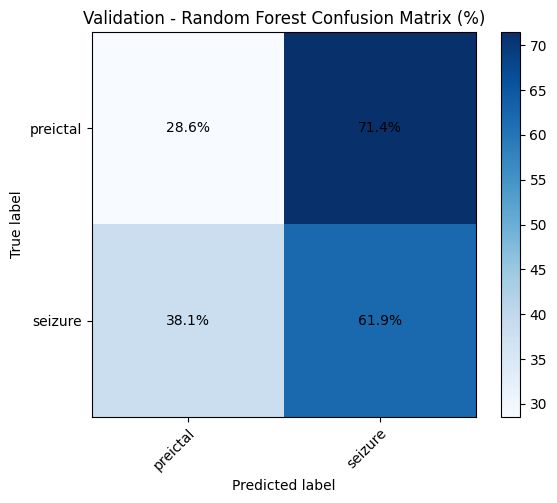


TEST - RANDOM FOREST SET

Classification table:
              precision    recall  f1-score    support
preictal       0.344828  0.370370  0.357143  27.000000
seizure        0.346154  0.321429  0.333333  28.000000
accuracy       0.345455  0.345455  0.345455   0.345455
macro avg      0.345491  0.345899  0.345238  55.000000
weighted avg   0.345503  0.345455  0.345022  55.000000

Global metrics:
Accuracy: 0.3455
Balanced accuracy: 0.3459
Macro F1: 0.3452


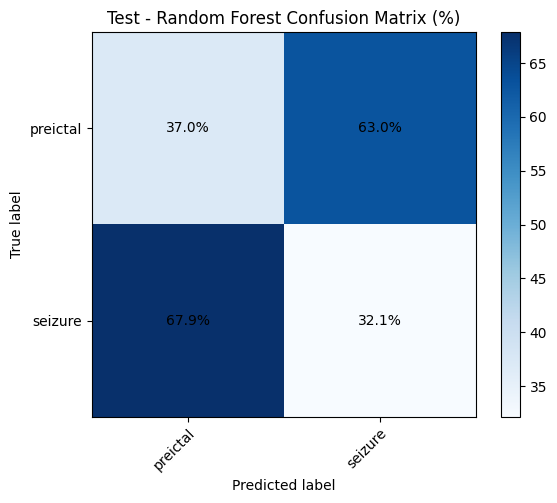

In [16]:
# ==========================================================
# EVALUATE RANDOM FOREST
# ==========================================================

# ----------------------------------------------------------
# Evaluate on the validation set
# ----------------------------------------------------------
val_results_rf = evaluate_and_plot(
    model=best_model_rf,
    X_data=X_val,
    y_true=y_val,
    class_names=class_names,
    dataset_name="Validation - Random Forest"
)

# ----------------------------------------------------------
# Evaluate on the test set
# ----------------------------------------------------------
test_results_rf = evaluate_and_plot(
    model=best_model_rf,
    X_data=X_test,
    y_true=y_test,
    class_names=class_names,
    dataset_name="Test - Random Forest"
)